platform_usage
Both         5.0
Instagram    6.0
TikTok       6.0
Name: anxiety_level, dtype: float64


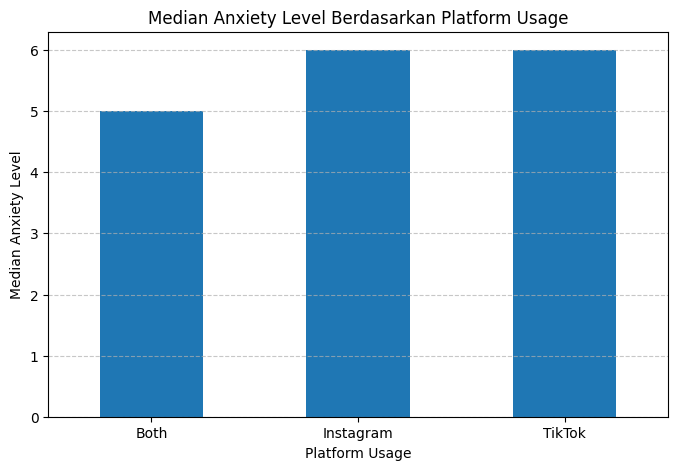

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(r"C:\Users\ADMIN\Downloads\Kelas E_Teen Mental Health.csv")


median_anxiety = df.groupby('platform_usage')['anxiety_level'].median()


print(median_anxiety)


plt.figure(figsize=(8,5))
median_anxiety.plot(kind='bar')

plt.title('Median Anxiety Level Berdasarkan Platform Usage')
plt.xlabel('Platform Usage')
plt.ylabel('Median Anxiety Level')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

     age  daily_social_media_hours  screen_time_before_sleep  \
0     14                       7.9                       2.9   
313   13                       8.0                       2.8   
462   13                       7.9                       2.7   
771   13                       7.6                       3.0   
404   13                       8.0                       2.5   

     total_screen_time  
0                 10.8  
313               10.8  
462               10.6  
771               10.6  
404               10.5  


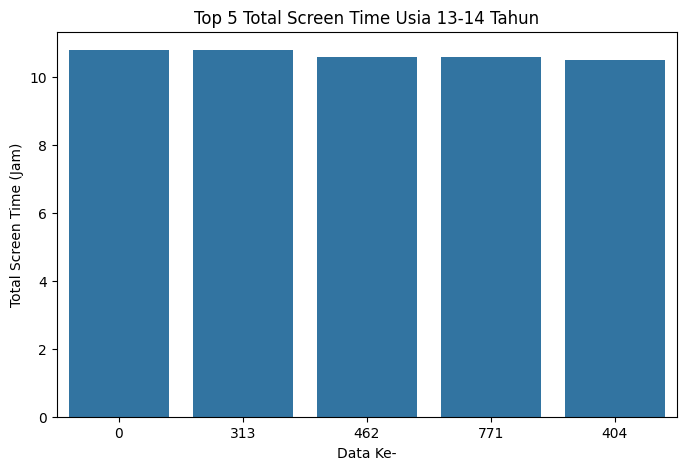

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\ADMIN\Downloads\Kelas E_Teen Mental Health.csv")


filtered = df[df['age'].between(13, 14)]


filtered['total_screen_time'] = (
    filtered['daily_social_media_hours']
    + filtered['screen_time_before_sleep']
)


top5 = filtered.nlargest(5, 'total_screen_time')

print(top5[['age',
            'daily_social_media_hours',
            'screen_time_before_sleep',
            'total_screen_time']])


plt.figure(figsize=(8,5))

sns.barplot(
    x=top5.index.astype(str),
    y='total_screen_time',
    data=top5
)

plt.title('Top 5 Total Screen Time Usia 13-14 Tahun')
plt.xlabel('Data Ke-')
plt.ylabel('Total Screen Time (Jam)')

plt.show()


                 stress_level  anxiety_level  addiction_level
stress_level         1.000000       0.015811        -0.000129
anxiety_level        0.015811       1.000000         0.031154
addiction_level     -0.000129       0.031154         1.000000


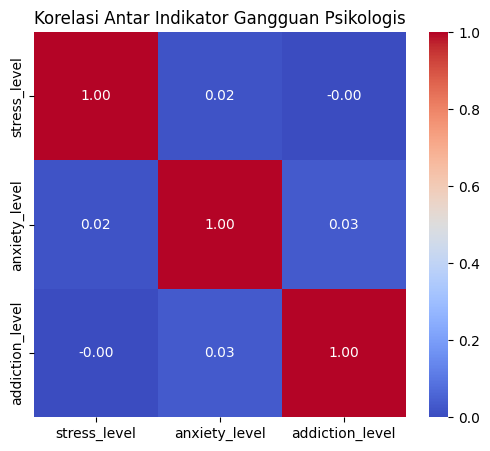

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\ADMIN\Downloads\Kelas E_Teen Mental Health.csv")

psychology = df[
    ['stress_level',
     'anxiety_level',
     'addiction_level']
]

corr_matrix = psychology.corr()

print(corr_matrix)

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Korelasi Antar Indikator Gangguan Psikologis')

plt.show()

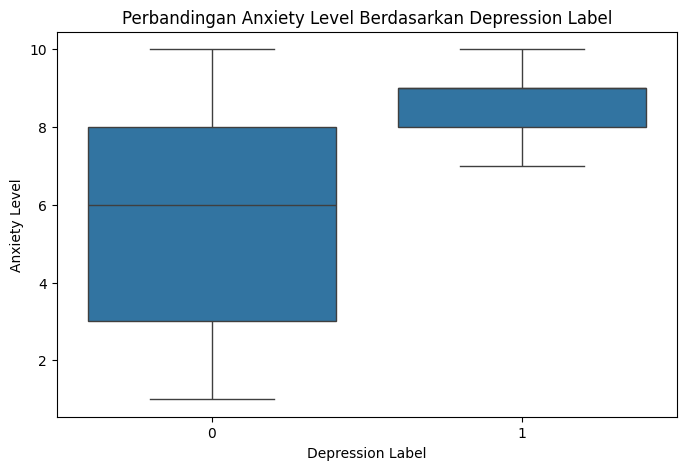

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\ADMIN\Downloads\Kelas E_Teen Mental Health.csv")

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='depression_label',
    y='anxiety_level'
)

plt.title(
    'Perbandingan Anxiety Level Berdasarkan Depression Label'
)

plt.xlabel('Depression Label')
plt.ylabel('Anxiety Level')

plt.show()

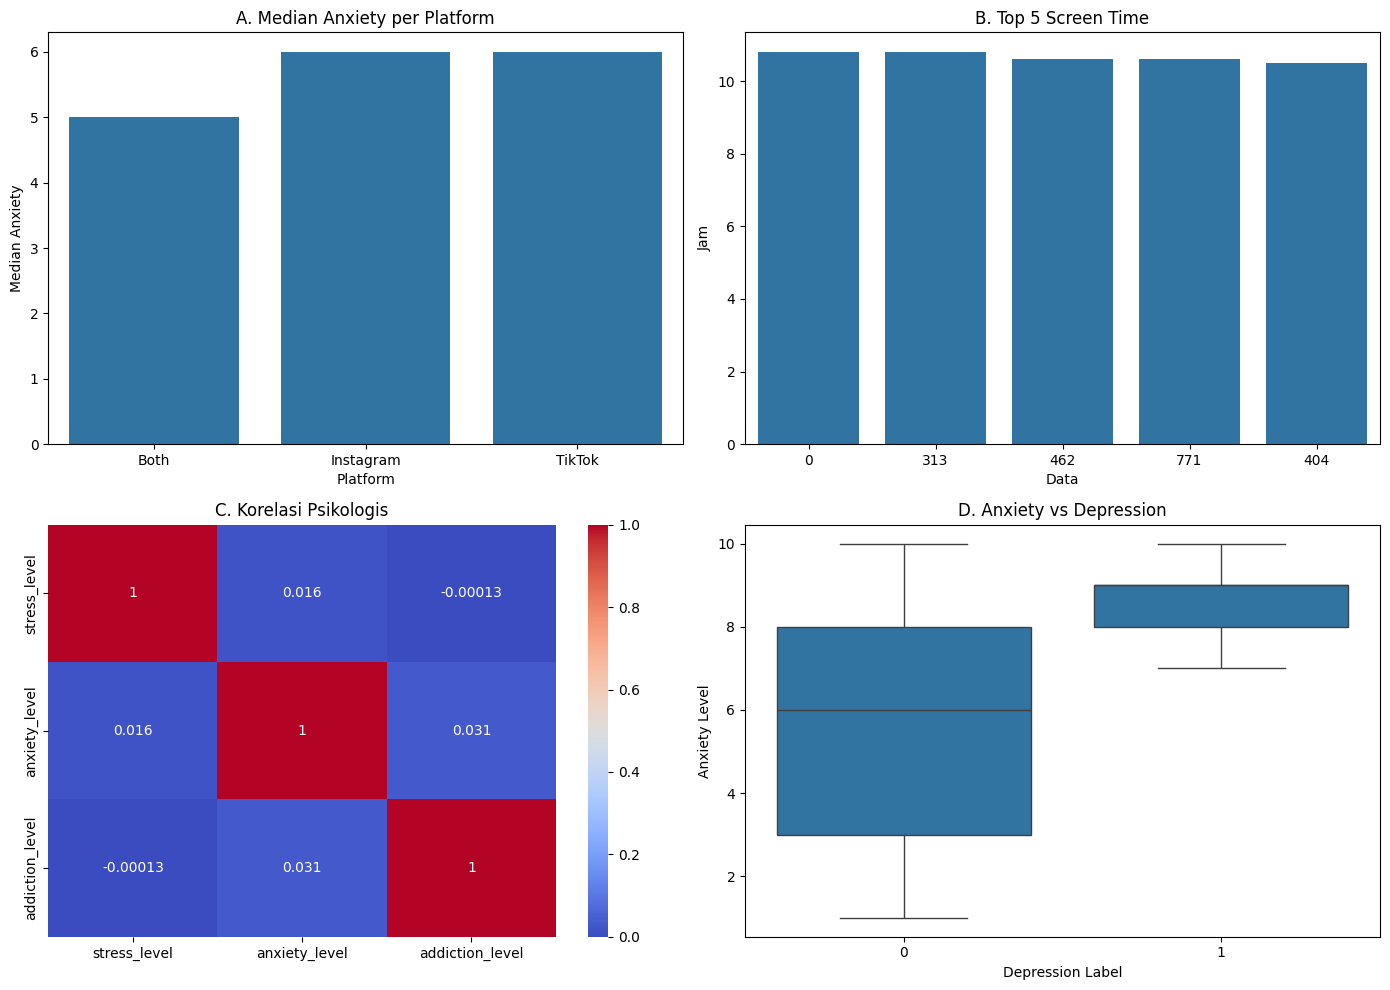

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(r"C:\Users\ADMIN\Downloads\Kelas E_Teen Mental Health.csv")


fig, ax = plt.subplots(2, 2, figsize=(14,10))

median_anxiety = (
    df.groupby('platform_usage')['anxiety_level']
      .median()
      .reset_index()
)

sns.barplot(
    data=median_anxiety,
    x='platform_usage',
    y='anxiety_level',
    ax=ax[0,0]
)

ax[0,0].set_title('A. Median Anxiety per Platform')
ax[0,0].set_xlabel('Platform')
ax[0,0].set_ylabel('Median Anxiety')

filtered = df[df['age'].between(13,14)].copy()

filtered['total_screen_time'] = (
    filtered['daily_social_media_hours']
    + filtered['screen_time_before_sleep']
)

top5 = filtered.nlargest(5,'total_screen_time')

sns.barplot(
    x=top5.index.astype(str),
    y=top5['total_screen_time'],
    ax=ax[0,1]
)

ax[0,1].set_title('B. Top 5 Screen Time')
ax[0,1].set_xlabel('Data')
ax[0,1].set_ylabel('Jam')

corr = df[
    ['stress_level',
     'anxiety_level',
     'addiction_level']
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    ax=ax[1,0]
)

ax[1,0].set_title('C. Korelasi Psikologis')

sns.boxplot(
    data=df,
    x='depression_label',
    y='anxiety_level',
    ax=ax[1,1]
)

ax[1,1].set_title('D. Anxiety vs Depression')
ax[1,1].set_xlabel('Depression Label')
ax[1,1].set_ylabel('Anxiety Level')

plt.tight_layout()

plt.show()